Important Functions:

In [2]:
import numpy as np                   #importing numpy package for scientific computing
import matplotlib.pyplot as plt      #importing matplotlib package for plots
from scipy.signal import welch
import matplotlib
from matplotlib import animation
import pandas as pd


def load_data(filepath):
    # Load all data from the file, skipping the 7-line header
    raw = np.genfromtxt(filepath, delimiter=";", skip_header=7)

    time = raw[:, 0]
    EMF1 = raw[:, 1]
    EMF2 = raw[:, 2]
    EMF3 = raw[:, 3]
    EMF4 = raw[:, 4]
    EMF5 = raw[:, 5]

    # Remove the mean of the first 60 seconds (still water baseline)
    # This way any mean current in the signal is preserved
    still_water_mask = time < 60
    EMF1 -= np.mean(EMF1[still_water_mask])
    EMF2 -= np.mean(EMF2[still_water_mask])
    EMF3 -= np.mean(EMF3[still_water_mask])
    EMF4 -= np.mean(EMF4[still_water_mask])
    EMF5 -= np.mean(EMF5[still_water_mask])

    # Now trim the first and last 60 seconds
    mask = (time >= 200) & (time <= time[-1] - 200)
    time = time[mask]
    EMF1, EMF2, EMF3, EMF4, EMF5 = EMF1[mask], EMF2[mask], EMF3[mask], EMF4[mask], EMF5[mask]
    EMF1, EMF2, EMF3, EMF4, EMF5 = EMF1 * 0.1023, EMF2 * 0.1023, EMF3 * 0.1023, EMF4 * 0.1023, EMF5 * 0.1023
    return time, EMF1, EMF2, EMF3, EMF4, EMF5

def plot_time_series(time, EMF1, EMF2, EMF3, EMF4, EMF5):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    for i, (ax, EMF) in enumerate(zip(axes, [EMF1, EMF2, EMF3, EMF4, EMF5]), start=1):
        ax.plot(time, EMF, label=f'EMF{i}')
        ax.set_ylabel('Velocity (m/s)')
        ax.set_title(f'EMF{i}')
        ax.legend(loc='upper right')
        ax.grid()

    axes[-1].set_xlabel('Time (s)')
    plt.suptitle('Time Series at all EMF locations')
    plt.tight_layout()
    plt.show()

def plot_time_series_limited(time, EMF1, EMF2, EMF3, EMF4, EMF5):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    for i, (ax, EMF) in enumerate(zip(axes, [EMF1, EMF2, EMF3, EMF4, EMF5]), start=1):
        ax.plot(time, EMF, label=f'EMF{i}')
        ax.set_ylabel('Velocity (m/s)')
        ax.set_title(f'EMF{i}')
        ax.legend(loc='upper right')
        ax.grid()

    axes[-1].set_xlabel('Time (s)')
    axes[-1].set_xlim(400, 420)
    plt.suptitle('Time Series at all EMF locations')
    plt.tight_layout()
    plt.show()

def read_grid(name_table, nx):
    grp = np.loadtxt(name_table, skiprows=0)
    ns, no = grp.shape
    nt = round(ns/nx)
    A = np.reshape(grp, (nx, nt, no), order="F")
    x    =  A[:, 0, 1]
    zbed = -A[:, 0, 3]

    # Shift zbed so the flat bottom starts at 0
    zbed = zbed - zbed.min()

    # Water depth at each EMF location (1-6)


    return x, zbed

def plot_flume(x, zbed, setup):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]

    water_levels  = {1: 0.510, 2: 0.509, 3: 0.508, 4: 0.507, 5: 0.506, 6: 0.505}
    water_level = water_levels[setup]

    plt.figure(figsize=(14, 4))
    plt.plot(x, zbed, color='black', label='Bed profile')
    plt.fill_between(x, zbed, 0, color='sandybrown', alpha=0.5)
    plt.axhline(y=water_level, color='blue', alpha=0.3, label=f'Water surface (h={water_level}m)')



    for i, pos in enumerate(emf_positions):
        plt.axvline(x=pos, linestyle='--', label=f'EMF{i+1} ({pos}m)')

    plt.xlabel('x (m)')
    plt.ylabel('Elevation (m)')
    plt.title('Flume bed profile with EMF sensor locations')
    plt.legend(loc='upper left')
    plt.grid()
    plt.show()

def plot_sediment_transport(time, EMF1, EMF2, EMF3, EMF4, EMF5, Fs):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]  # only 5 sensors
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5]  # only 5 sensors

    # --- Compute all terms at each EMF location ---
    u3            = []
    u3_ss         = []
    three_u2ss_u  = []
    three_u2ss_uig= []
    sed_total     = []

    for EMF in emf_data:
        u_mean      = np.mean(EMF)
        u_demeaned  = EMF - u_mean

        # Sea-swell band (0.05 - 1.0 Hz)
        u_ss        = frequency_filter(u_demeaned, Fs, f_low=0.05, f_high=1.0)

        # Infragravity band (0.005 - 0.05 Hz)
        u_ig        = frequency_filter(u_demeaned, Fs, f_low=0.005, f_high=0.05)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    # --- Plot as points at the 5 EMF locations ---
    plt.figure(figsize=(12, 4))
    plt.plot(emf_positions, u3,             label='Mean current',             color='red',    marker='o', markersize=4)
    plt.plot(emf_positions, u3_ss,          label='Skewness',                 color='blue',   marker='o', markersize=4)
    plt.plot(emf_positions, three_u2ss_u,   label='Stirring term',            color='green',  marker='o', markersize=4)
    plt.plot(emf_positions, three_u2ss_uig, label='Infragravity term',        color='purple', marker='o', markersize=4)
    plt.plot(emf_positions, sed_total,      label='Total sediment transport', color='black',  marker='o', markersize=4)

    plt.xlabel('x (m)')
    plt.ylabel('Sediment transport proxy (m³/s³)')
    plt.legend()
    plt.grid()
    plt.show()

def frequency_filter(data, Fs, f_low, f_high):
    ''' frequency_filter is a simple spectral filter in which the unwanted frequencies (below f_low and above f_high) 
        are set to zero before coming back to the time-domain
            input: data timeseries you want to filter
                   F_s the sampling frequency of this timeseries (Hz)
                   f_low and f_high are the limits of the band pass filter (Hz)
            output: data_filtered band pass filtered timeseries (same unit as the input timeseries)
    '''
    
    N = len(data)

    fft_data = np.fft.fft(data)  # fourier transform of the signal

    freq_vector = np.fft.fftfreq(N, d=1/Fs) # corresponding (2-sided) frequency axis (includes positive and negative values)
    
    idx = np.where((abs(freq_vector) > f_high) | (abs(freq_vector) <= f_low)) # we select the indices to filter out
    
    fft_data[idx]=0.  # we set the the fourier coefficients corresponding to abs(f)>f_high and abs(f)<f_low to zero

    data_filtered = np.fft.ifft(fft_data).real  # we come back to the time domain with an inverse Fourier transform
    
    return data_filtered

Grid Plot for Setup 1:

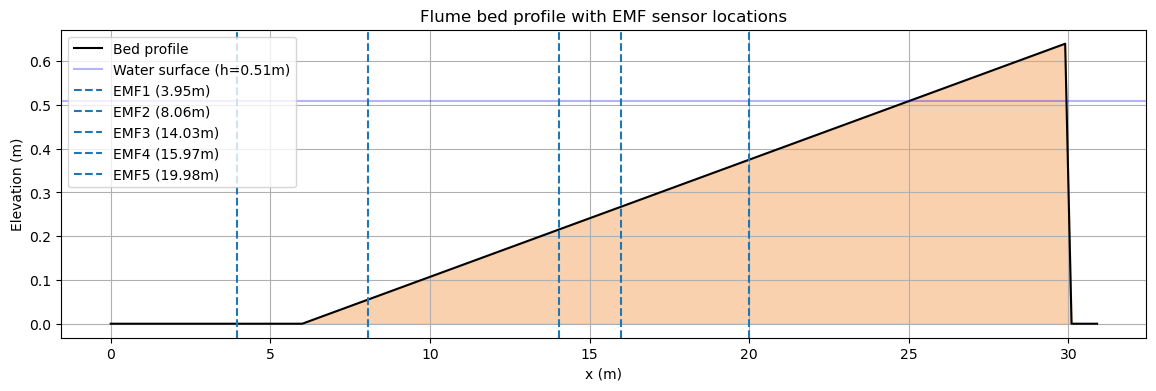

In [3]:
x, zbed = read_grid("grid_output.tbl", 310)
plot_flume(x, zbed, 1)

Plot Raw Velocity profiles at different sensor locations:

In [4]:
time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03 = load_data('Set1/EMF_test1.ASC')

Swash Simulations Functions:

In [9]:
def read_point_output(name_table):
    '''reads the wave gauge output type 
            input: name_table is the name of the output table (e.g. name_table="gauge1.tbl" in the original SWASH input file)
            outputs:
                t: vector containing the time in s
                eta: vector containing the surface elevation in m
                ux: vector containing the depth averaged horizontal velocity in m/s
    '''
    
    gauge = np.loadtxt(name_table,skiprows=7)

    t   = gauge[:,0] #time vector (s)
    ux  = gauge[:,2] #depth-averaged velocity in the x-direction (m/s)
    #uy = gauge[:,3] #depth-averaged velocity in the y-direction (0 at all time because we are looking at a 1D case)
    Eta = gauge[:,1] #surface elevation (m)
    return t, Eta, ux #, uy

def calculate_sediment_transport(time, EMF1, EMF2, EMF3, EMF4, EMF5, Fs):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5]

    u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total = [], [], [], [], []

    for EMF in emf_data:
        u_mean  = np.mean(EMF)
        u_dem   = EMF - u_mean
        u_ss    = frequency_filter(u_dem, Fs, f_low=0.15,  f_high=1.3)
        u_ig    = frequency_filter(u_dem, Fs, f_low=0.005, f_high=0.15)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    return emf_positions, u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total


Get the Data from Simulations:

In [10]:
time1_swash, Eta1_1, ux1_1 = read_point_output('Set1Swash/gauge1.tbl')
time1_swash, Eta1_2, ux1_2 = read_point_output('Set1Swash/gauge2.tbl')
time1_swash, Eta1_3, ux1_3 = read_point_output('Set1Swash/gauge3.tbl')
time1_swash, Eta1_4, ux1_4 = read_point_output('Set1Swash/gauge4.tbl')
time1_swash, Eta1_5, ux1_5 = read_point_output('Set1Swash/gauge5.tbl')
time1_swash, Eta1_6, ux1_6 = read_point_output('Set1Swash/gauge6.tbl')

time2_swash, Eta2_1, ux2_1 = read_point_output('Set2Swash/gauge1.tbl')
time2_swash, Eta2_2, ux2_2 = read_point_output('Set2Swash/gauge2.tbl')
time2_swash, Eta2_3, ux2_3 = read_point_output('Set2Swash/gauge3.tbl')
time2_swash, Eta2_4, ux2_4 = read_point_output('Set2Swash/gauge4.tbl')
time2_swash, Eta2_5, ux2_5 = read_point_output('Set2Swash/gauge5.tbl')
time2_swash, Eta2_6, ux2_6 = read_point_output('Set2Swash/gauge6.tbl')

time3_swash, Eta3_1, ux3_1 = read_point_output('Set3Swash/gauge1.tbl')
time3_swash, Eta3_2, ux3_2 = read_point_output('Set3Swash/gauge2.tbl')
time3_swash, Eta3_3, ux3_3 = read_point_output('Set3Swash/gauge3.tbl')
time3_swash, Eta3_4, ux3_4 = read_point_output('Set3Swash/gauge4.tbl')
time3_swash, Eta3_5, ux3_5 = read_point_output('Set3Swash/gauge5.tbl')
time3_swash, Eta3_6, ux3_6 = read_point_output('Set3Swash/gauge6.tbl')

time4_swash, Eta4_1, ux4_1 = read_point_output('Set4Swash/gauge1.tbl')
time4_swash, Eta4_2, ux4_2 = read_point_output('Set4Swash/gauge2.tbl')
time4_swash, Eta4_3, ux4_3 = read_point_output('Set4Swash/gauge3.tbl')
time4_swash, Eta4_4, ux4_4 = read_point_output('Set4Swash/gauge4.tbl')
time4_swash, Eta4_5, ux4_5 = read_point_output('Set4Swash/gauge5.tbl')
time4_swash, Eta4_6, ux4_6 = read_point_output('Set4Swash/gauge6.tbl')

time5_swash, Eta5_1, ux5_1 = read_point_output('Set5Swash/gauge1.tbl')
time5_swash, Eta5_2, ux5_2 = read_point_output('Set5Swash/gauge2.tbl')
time5_swash, Eta5_3, ux5_3 = read_point_output('Set5Swash/gauge3.tbl')
time5_swash, Eta5_4, ux5_4 = read_point_output('Set5Swash/gauge4.tbl')
time5_swash, Eta5_5, ux5_5 = read_point_output('Set5Swash/gauge5.tbl')
time5_swash, Eta5_6, ux5_6 = read_point_output('Set5Swash/gauge6.tbl')

time6_swash, Eta6_1, ux6_1 = read_point_output('Set6Swash/gauge1.tbl')
time6_swash, Eta6_2, ux6_2 = read_point_output('Set6Swash/gauge2.tbl')
time6_swash, Eta6_3, ux6_3 = read_point_output('Set6Swash/gauge3.tbl')
time6_swash, Eta6_4, ux6_4 = read_point_output('Set6Swash/gauge4.tbl')
time6_swash, Eta6_5, ux6_5 = read_point_output('Set6Swash/gauge5.tbl')
time6_swash, Eta6_6, ux6_6 = read_point_output('Set6Swash/gauge6.tbl')

time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06 = load_data('Set2/EMF_test2.ASC')
time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09 = load_data('Set3/EMF_test3.ASC')
time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12 = load_data('Set4/EMF_test4.ASC')
time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15 = load_data('Set5/EMF_test5.ASC')
time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18 = load_data('Set6/EMF_test6.ASC')

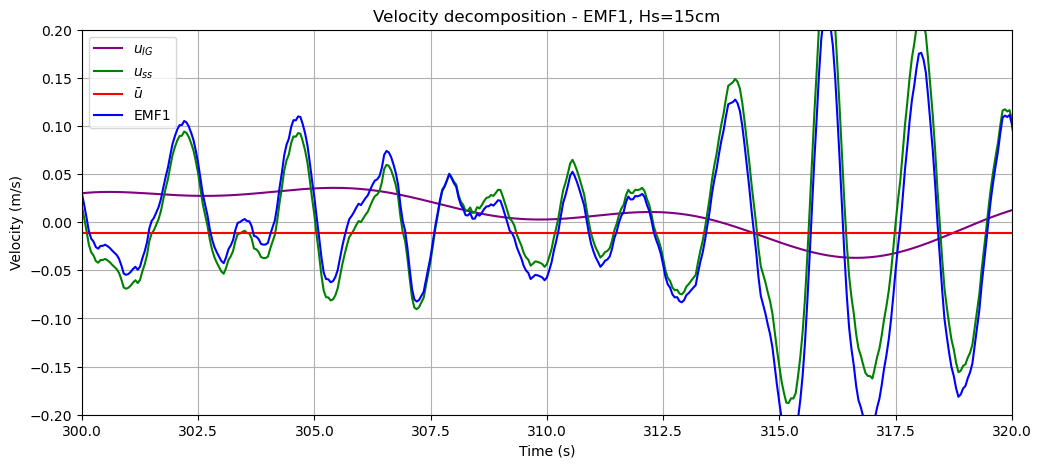

In [11]:
#plot decomposed signal
u_mean = np.mean(EMF1_15)
u_dem  = EMF1_15 - u_mean
u_ss   = frequency_filter(EMF1_15, Fs=20, f_low=0.15,  f_high=10.0)
u_ig_dem = frequency_filter(EMF1_15, Fs=20, f_low=0.005, f_high=0.15)
u_mean_array = np.full(len(time5), u_mean)

plt.figure(figsize=(12, 5))
plt.plot(time5, u_ig_dem,    color='purple', label='$u_{IG}$')
plt.plot(time5, u_ss,        color='green',  label='$u_{ss}$')
plt.plot(time5, u_mean_array,color='red',    label='$\\bar{u}$')
plt.plot(time5, EMF1_15,     color='blue',   label='EMF1')
plt.xlim(300, 320)
plt.ylim(-0.2, 0.2)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity decomposition - EMF1, Hs=15cm')
plt.legend()
plt.grid()
plt.show()

Plot Simulation against Experiment 3cm:

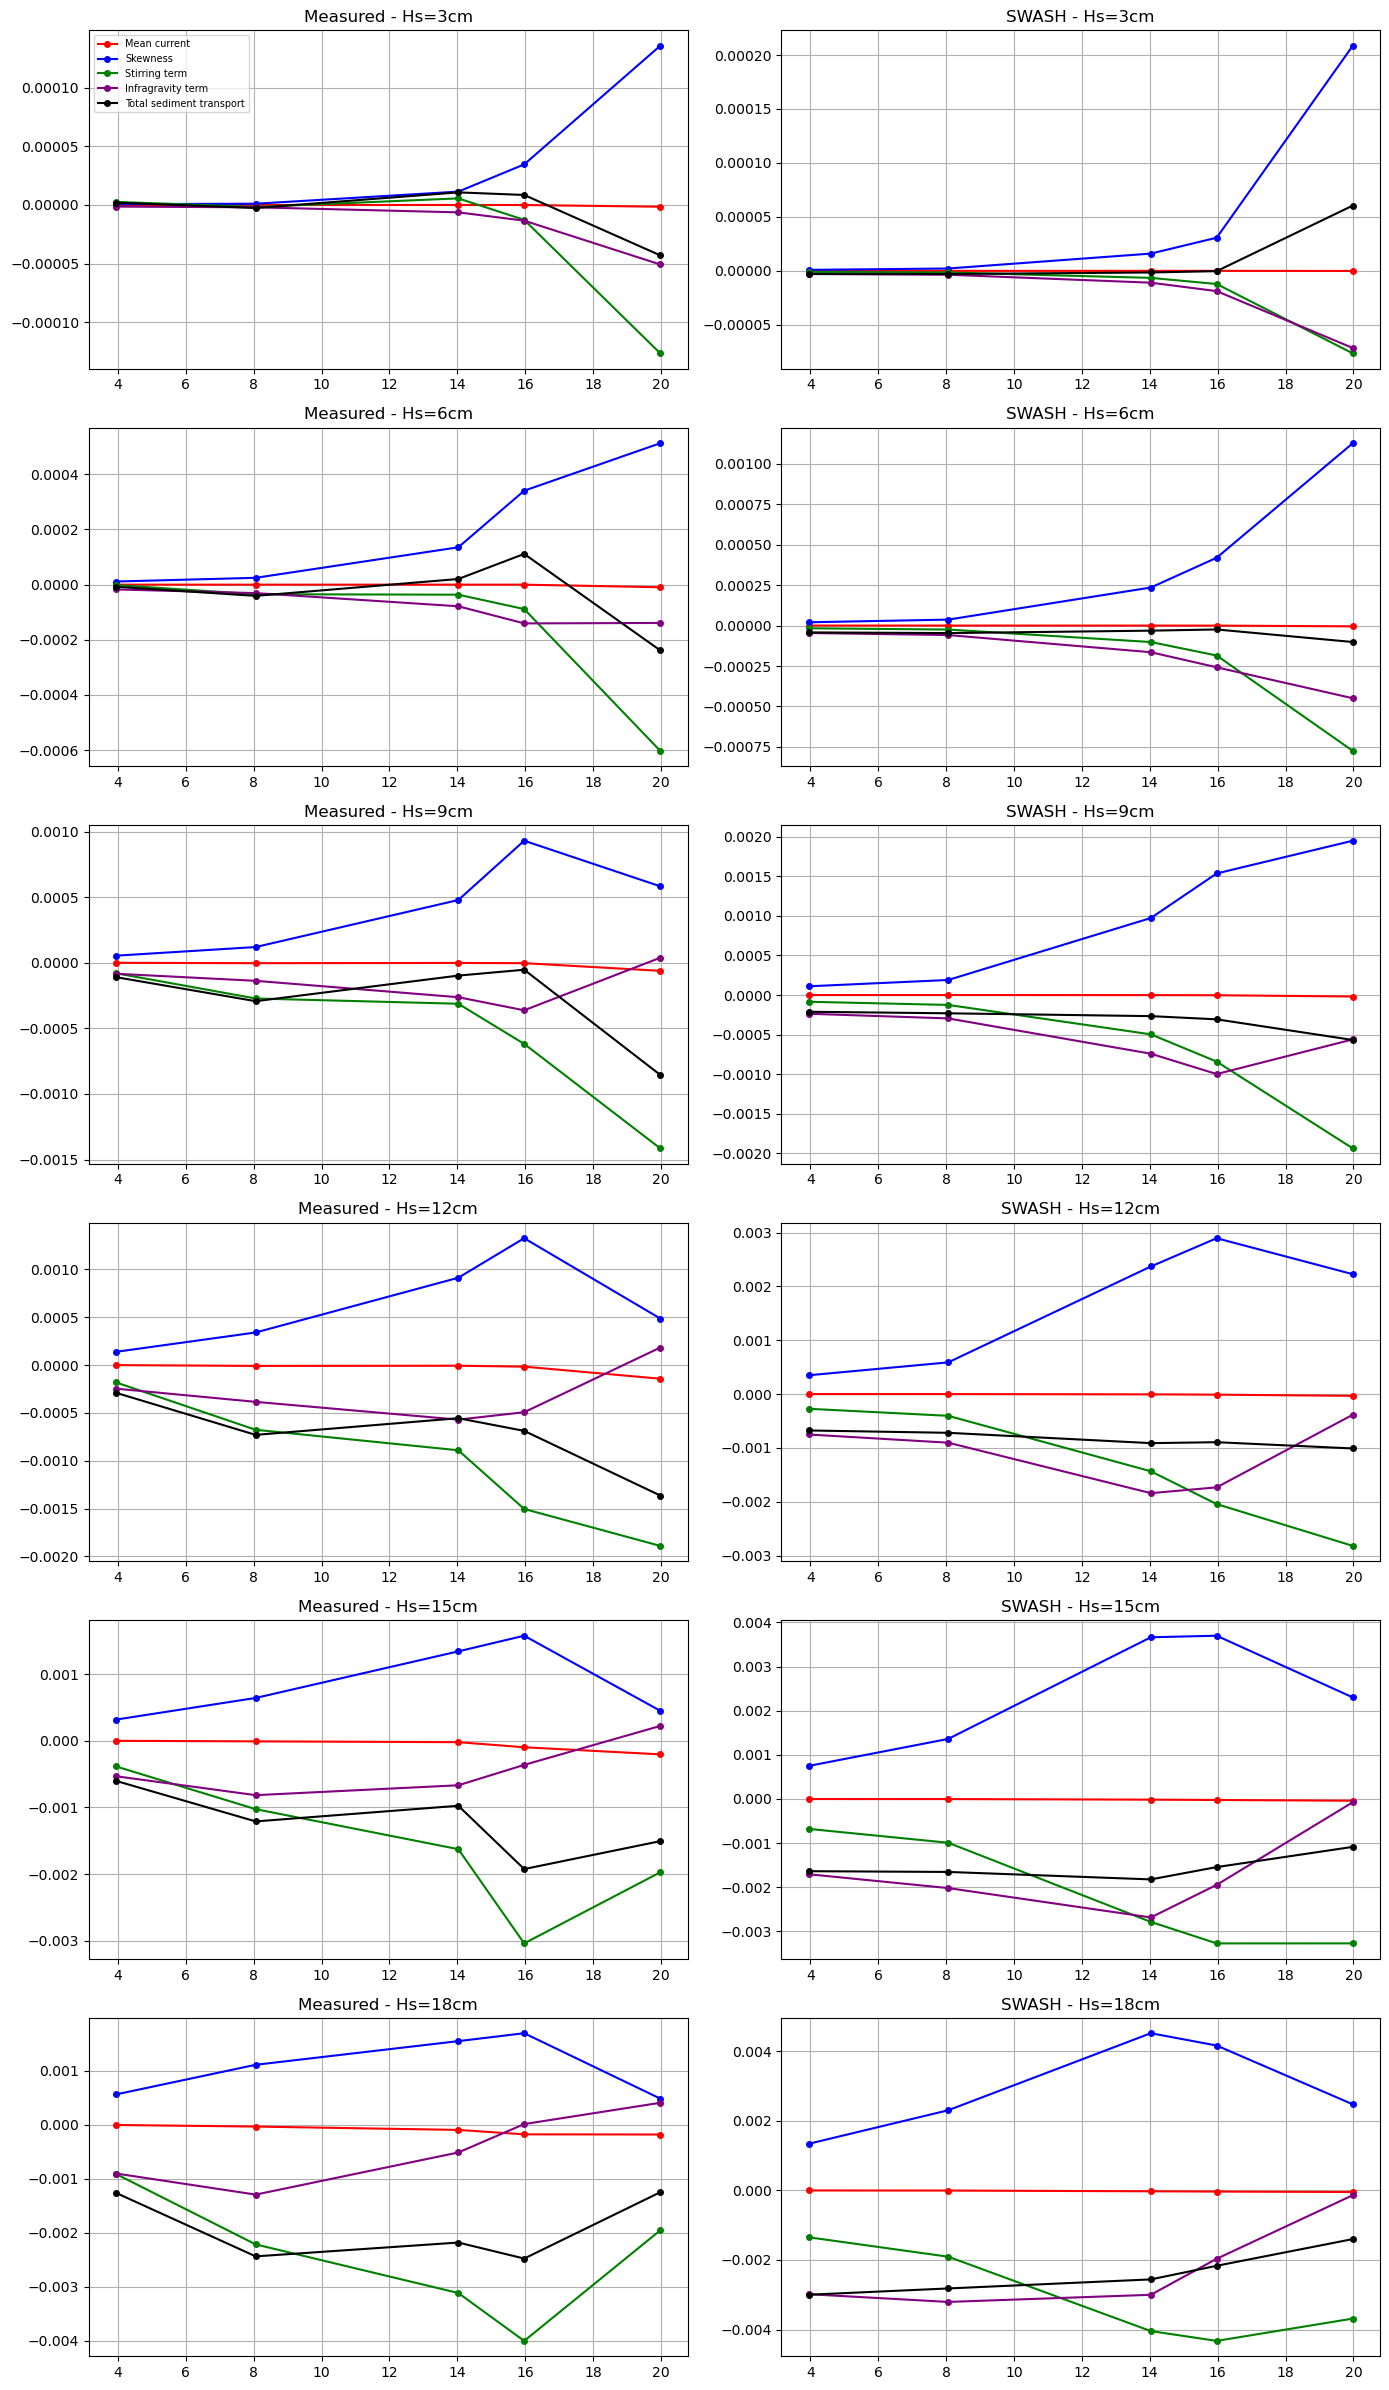

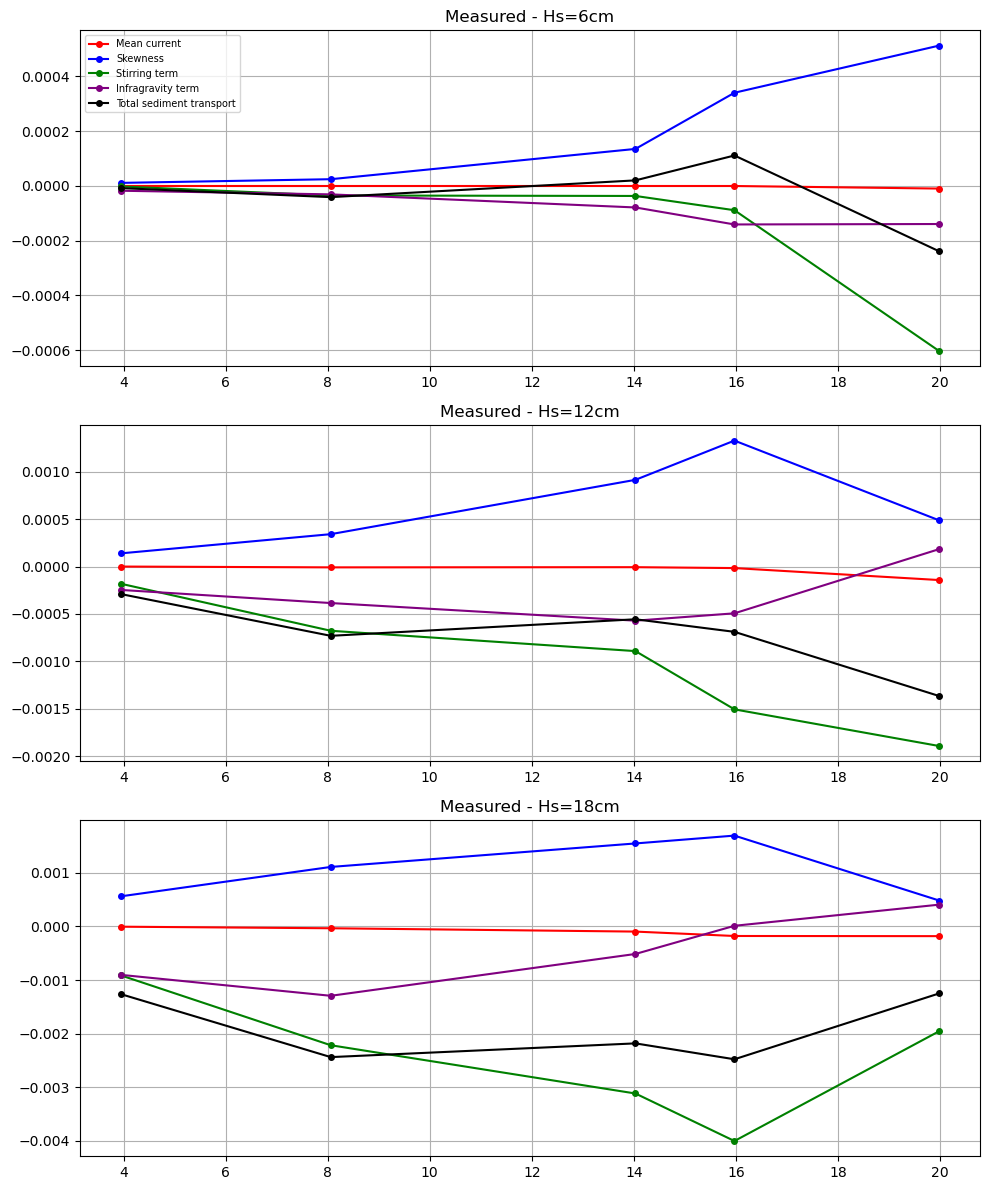

In [14]:
fig, axes = plt.subplots(6, 2, figsize=(14, 24))

datasets = [
    (time1,       EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, time1_swash, ux1_1, ux1_2, ux1_3, ux1_4, ux1_5, '3cm'),
    (time2,       EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, time2_swash, ux2_1, ux2_2, ux2_3, ux2_4, ux2_5, '6cm'),
    (time3,       EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, time3_swash, ux3_1, ux3_2, ux3_3, ux3_4, ux3_5, '9cm'),
    (time4,       EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, time4_swash, ux4_1, ux4_2, ux4_3, ux4_4, ux4_5, '12cm'),
    (time5,       EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, time5_swash, ux5_1, ux5_2, ux5_3, ux5_4, ux5_5, '15cm'),
    (time6,       EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, time6_swash, ux6_1, ux6_2, ux6_3, ux6_4, ux6_5, '18cm'),
]

plot_kwargs = [
    {'label': 'Mean current',             'color': 'red',    'marker': 'o', 'markersize': 4},
    {'label': 'Skewness',                 'color': 'blue',   'marker': 'o', 'markersize': 4},
    {'label': 'Stirring term',            'color': 'green',  'marker': 'o', 'markersize': 4},
    {'label': 'Infragravity term',        'color': 'purple', 'marker': 'o', 'markersize': 4},
    {'label': 'Total sediment transport', 'color': 'black',  'marker': 'o', 'markersize': 4},
]

for i, (time_m, e1, e2, e3, e4, e5, time_s, u1, u2, u3, u4, u5, hs) in enumerate(datasets):
    pos_m, u3_m, u3_ss_m, stir_m, ig_m, tot_m = calculate_sediment_transport(time_m, e1, e2, e3, e4, e5, Fs=20)
    pos_s, u3_s, u3_ss_s, stir_s, ig_s, tot_s = calculate_sediment_transport(time_s, u1, u2, u3, u4, u5, Fs=20)

    for values, ax, pos in [(  [u3_m, u3_ss_m, stir_m, ig_m, tot_m], axes[i, 0], pos_m),
                             (  [u3_s, u3_ss_s, stir_s, ig_s, tot_s], axes[i, 1], pos_s)]:
        for vals, kwargs in zip(values, plot_kwargs):
            ax.plot(pos, vals, **kwargs)
        ax.grid()

    axes[i, 0].set_title(f'Measured - Hs={hs}')
    axes[i, 1].set_title(f'SWASH - Hs={hs}')

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

datasets_filtered = [
    (time1, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, '6cm'),
    (time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, '12cm'),
    (time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, '18cm'),
]

for ax, (time_m, e1, e2, e3, e4, e5, hs) in zip(axes, datasets_filtered):
    pos_m, u3_m, u3_ss_m, stir_m, ig_m, tot_m = calculate_sediment_transport(time_m, e1, e2, e3, e4, e5, Fs=20)
    for vals, kwargs in zip([u3_m, u3_ss_m, stir_m, ig_m, tot_m], plot_kwargs):
        ax.plot(pos_m, vals, **kwargs)
    ax.set_title(f'Measured - Hs={hs}')
    ax.grid()

axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

Compute the Wave Spectrum

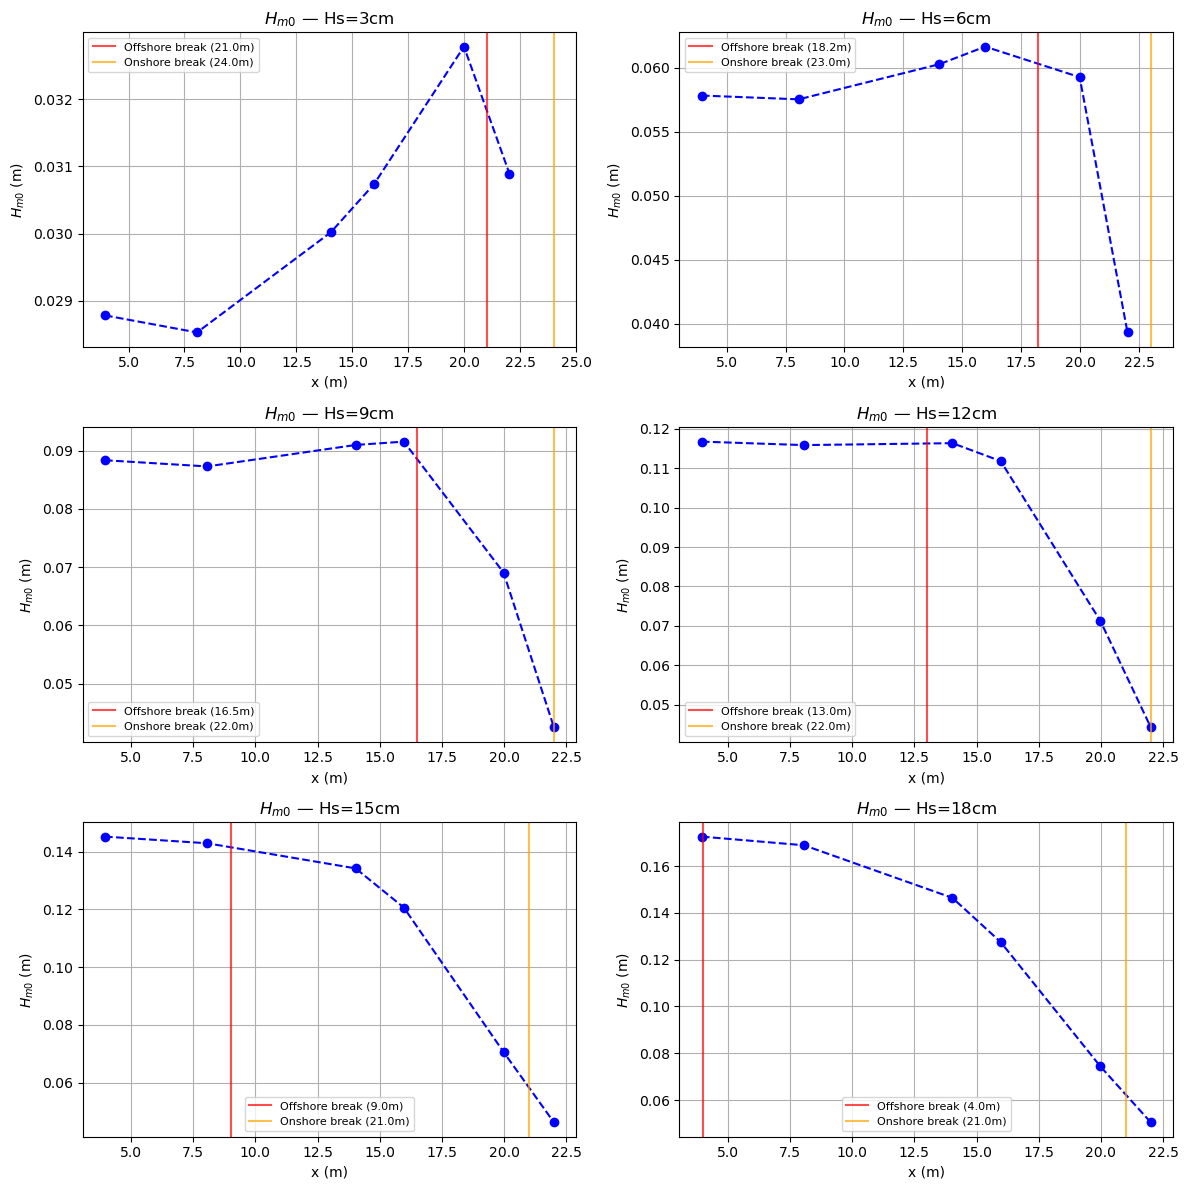

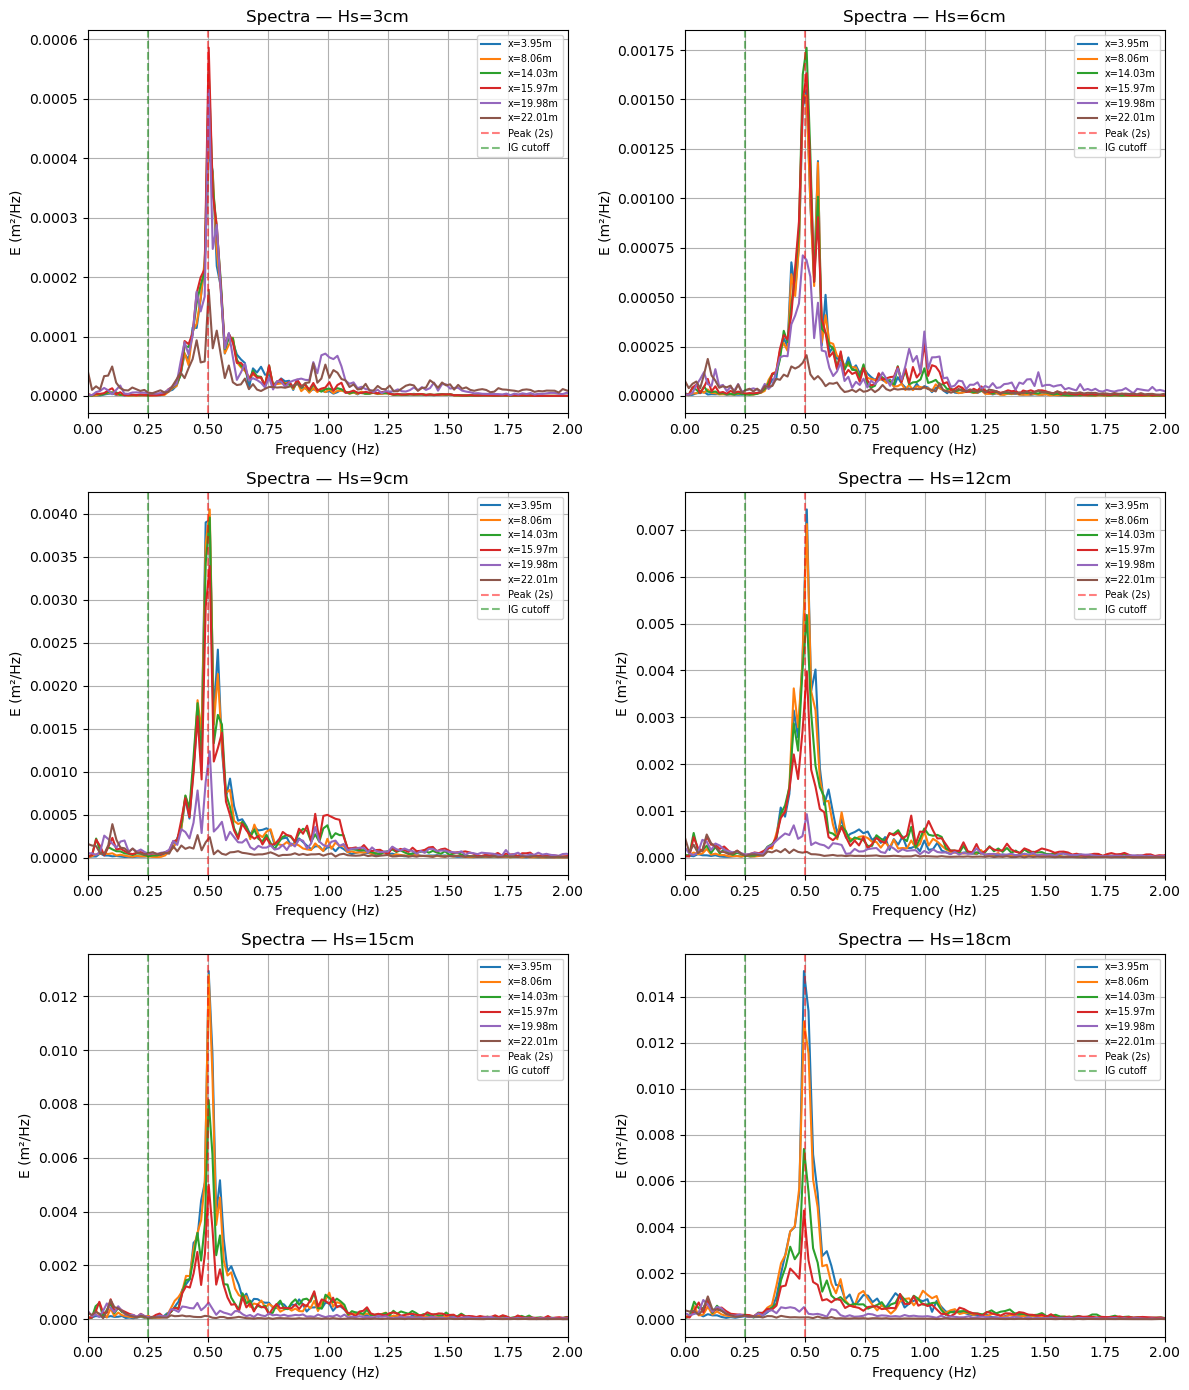

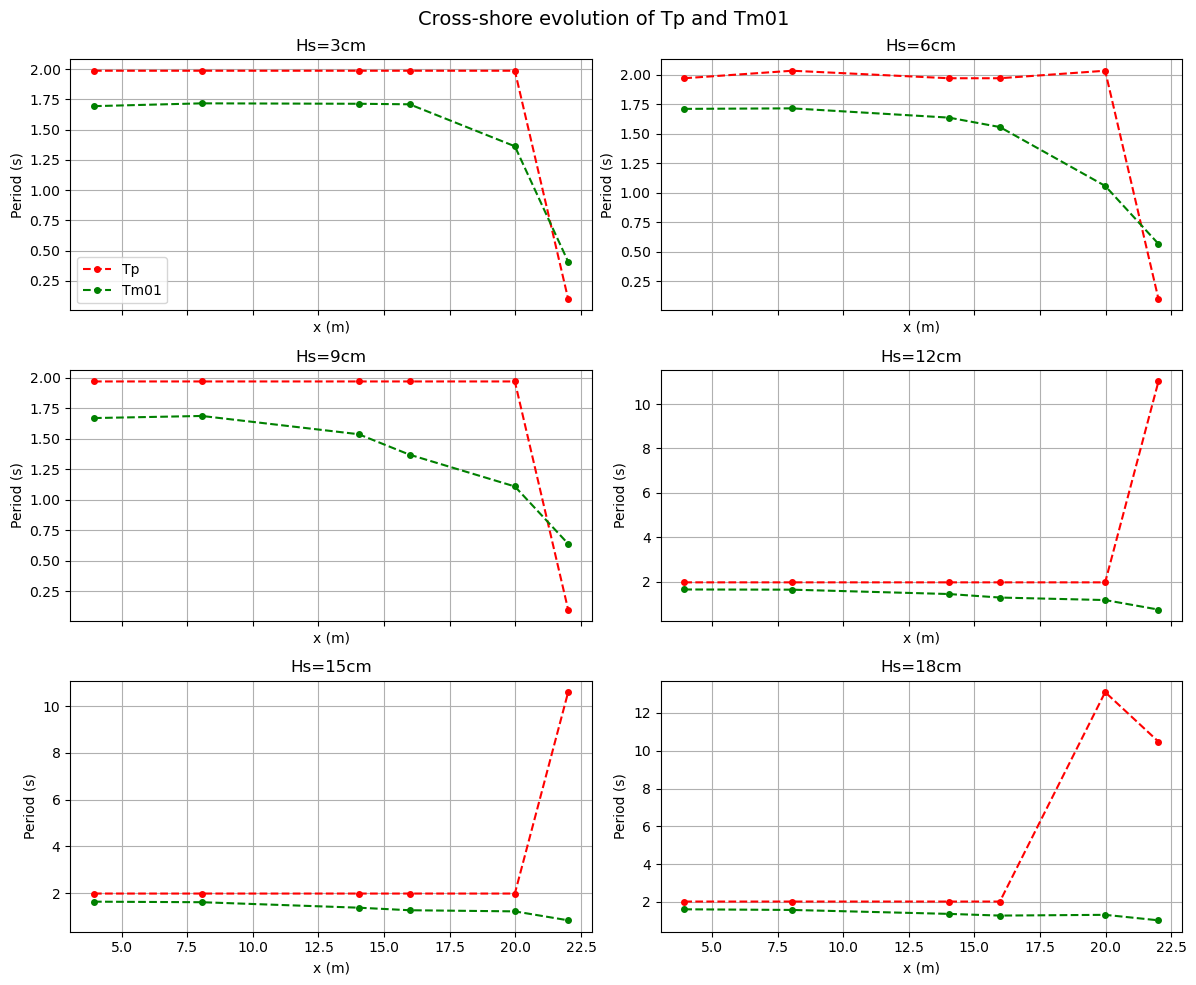

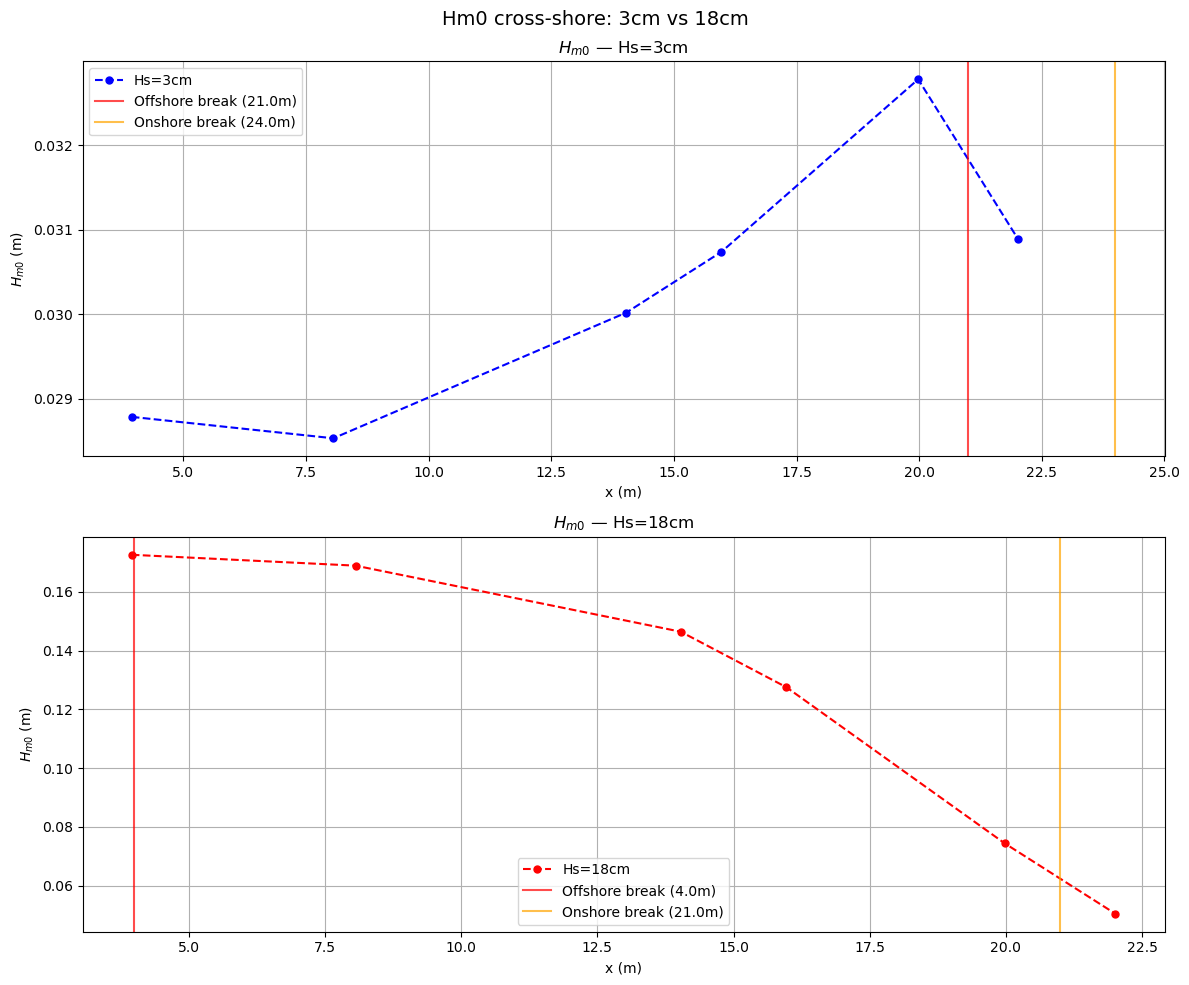

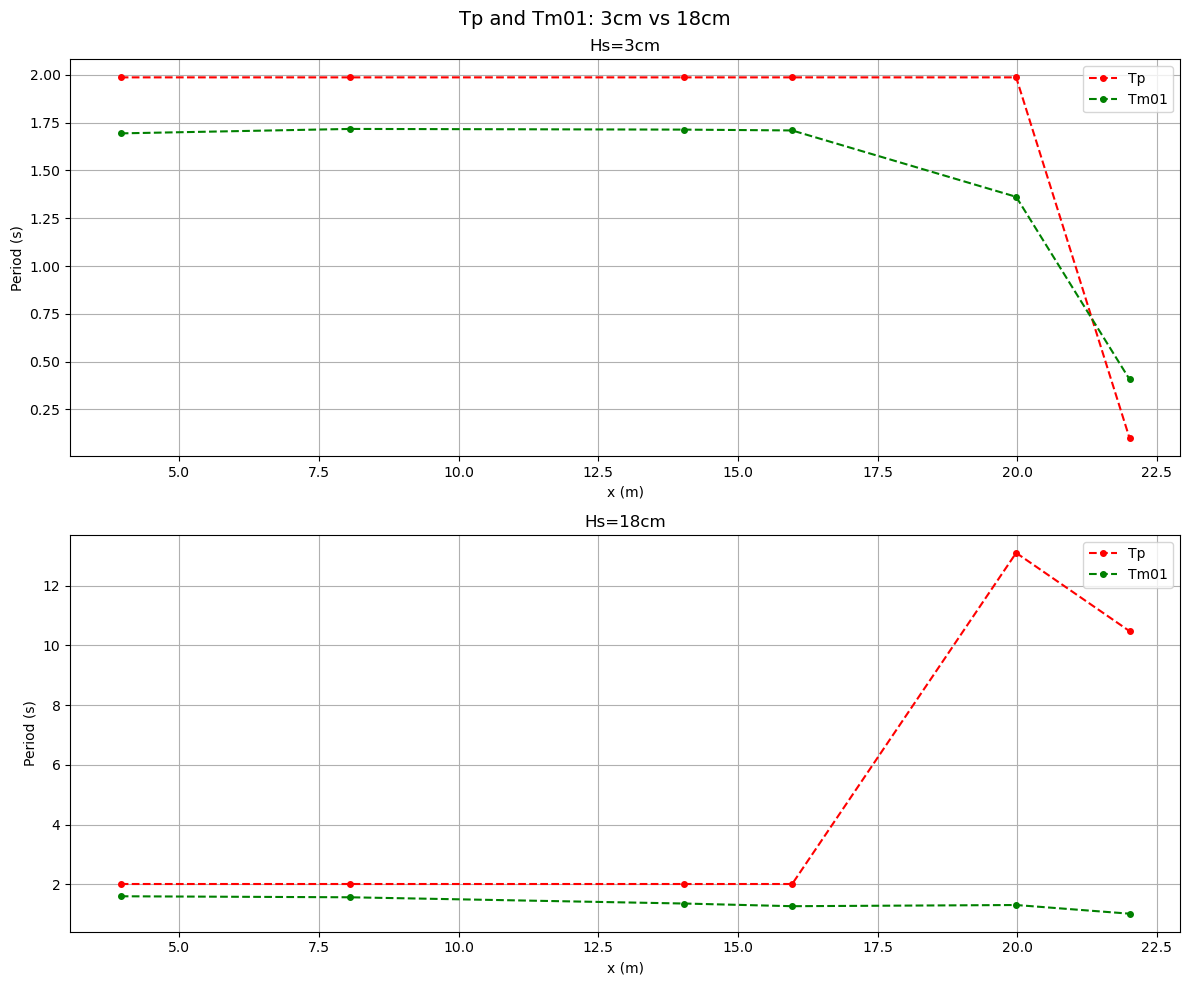

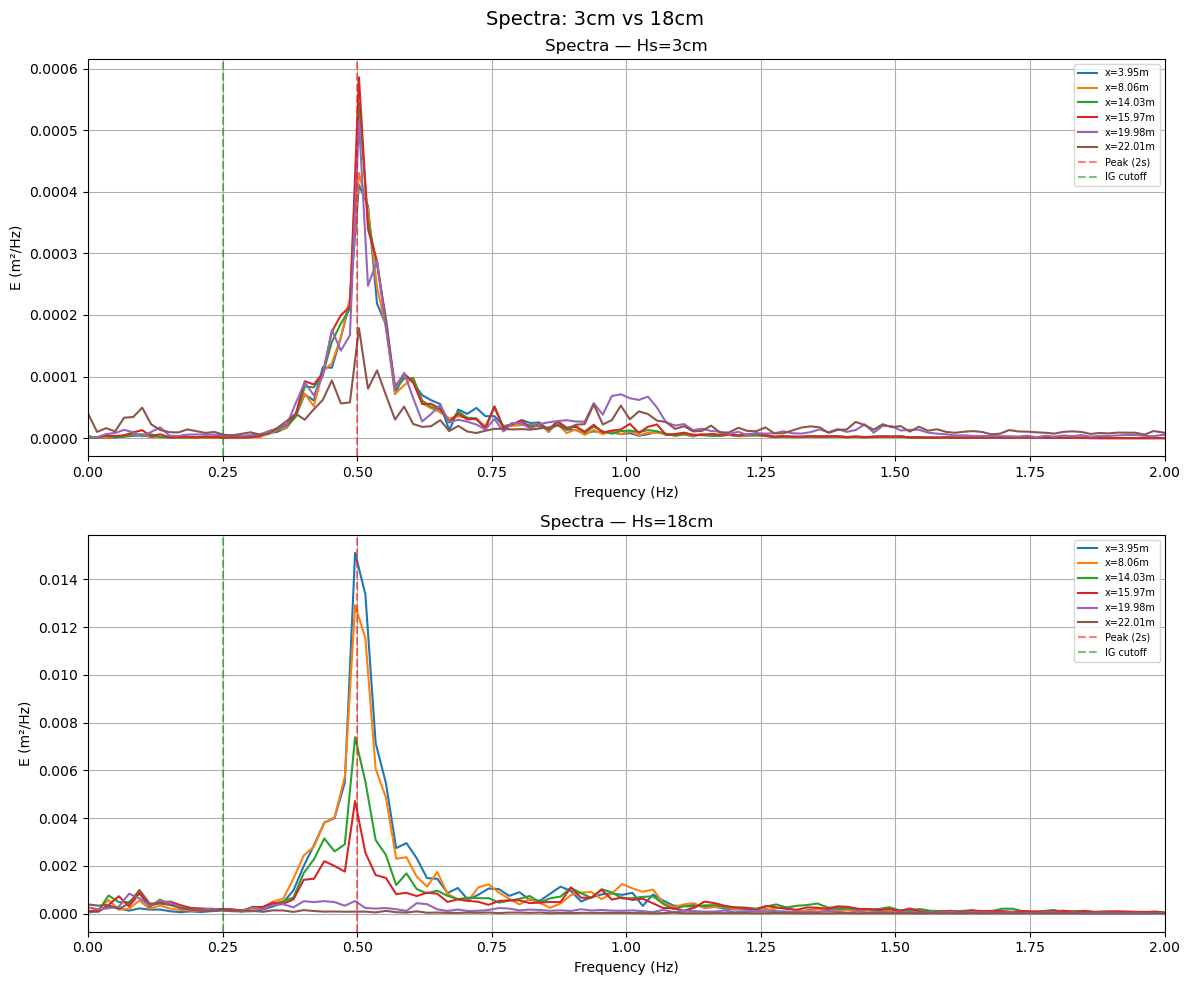

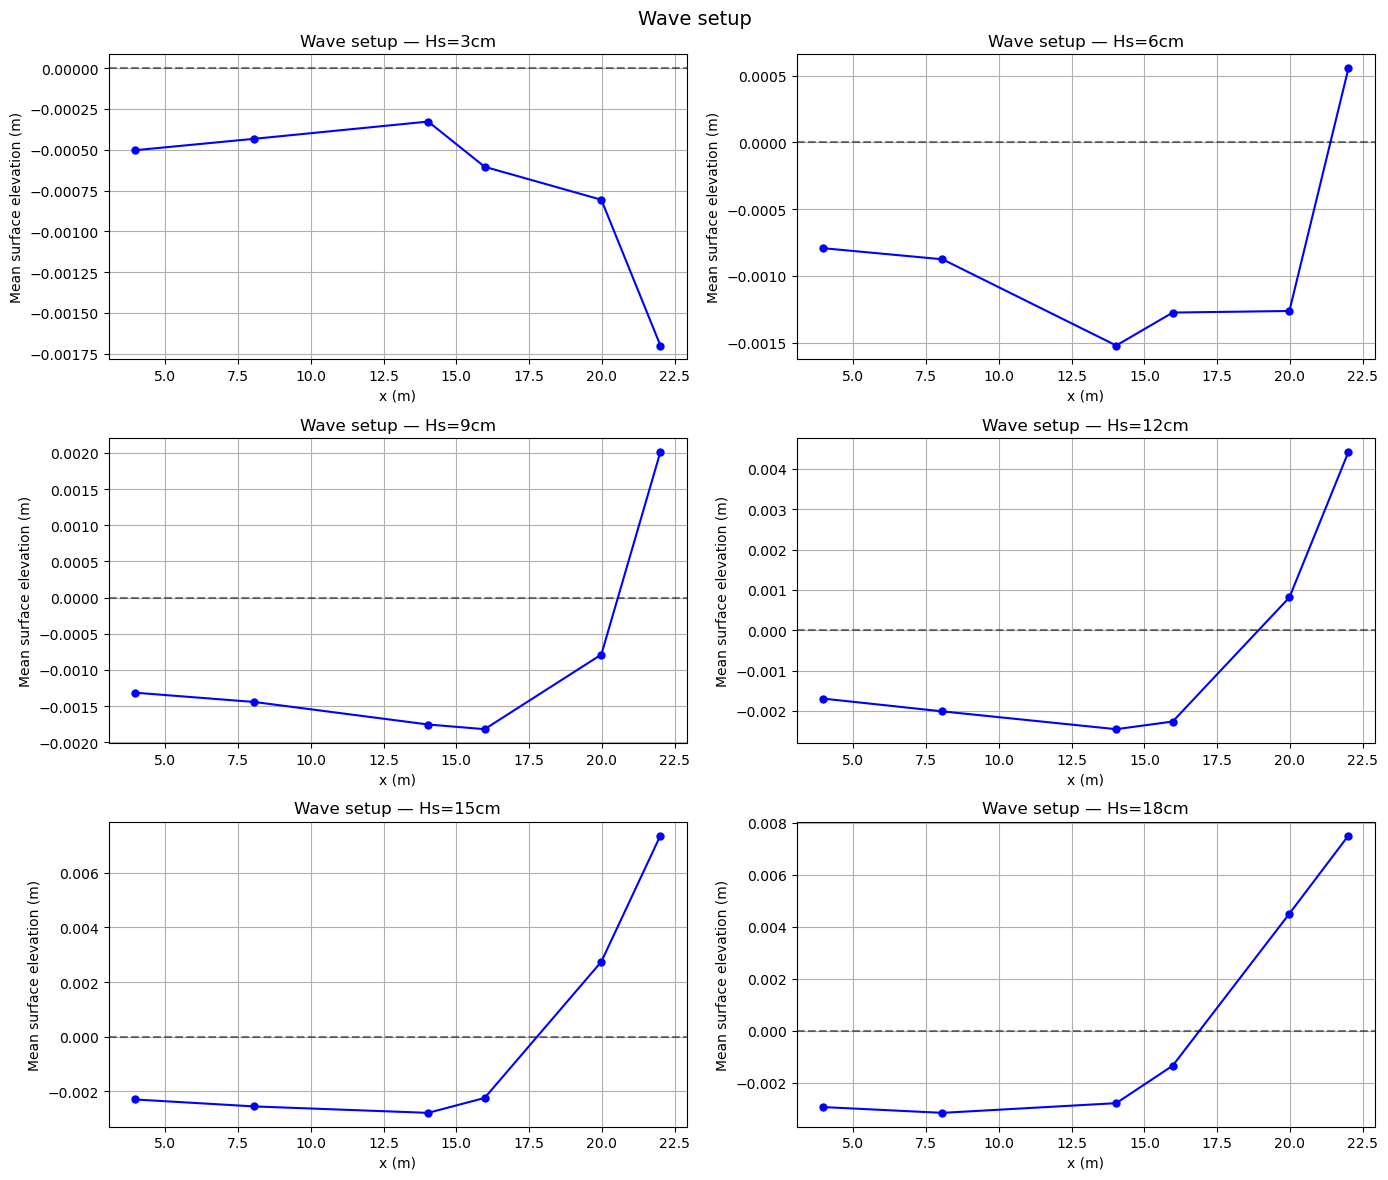

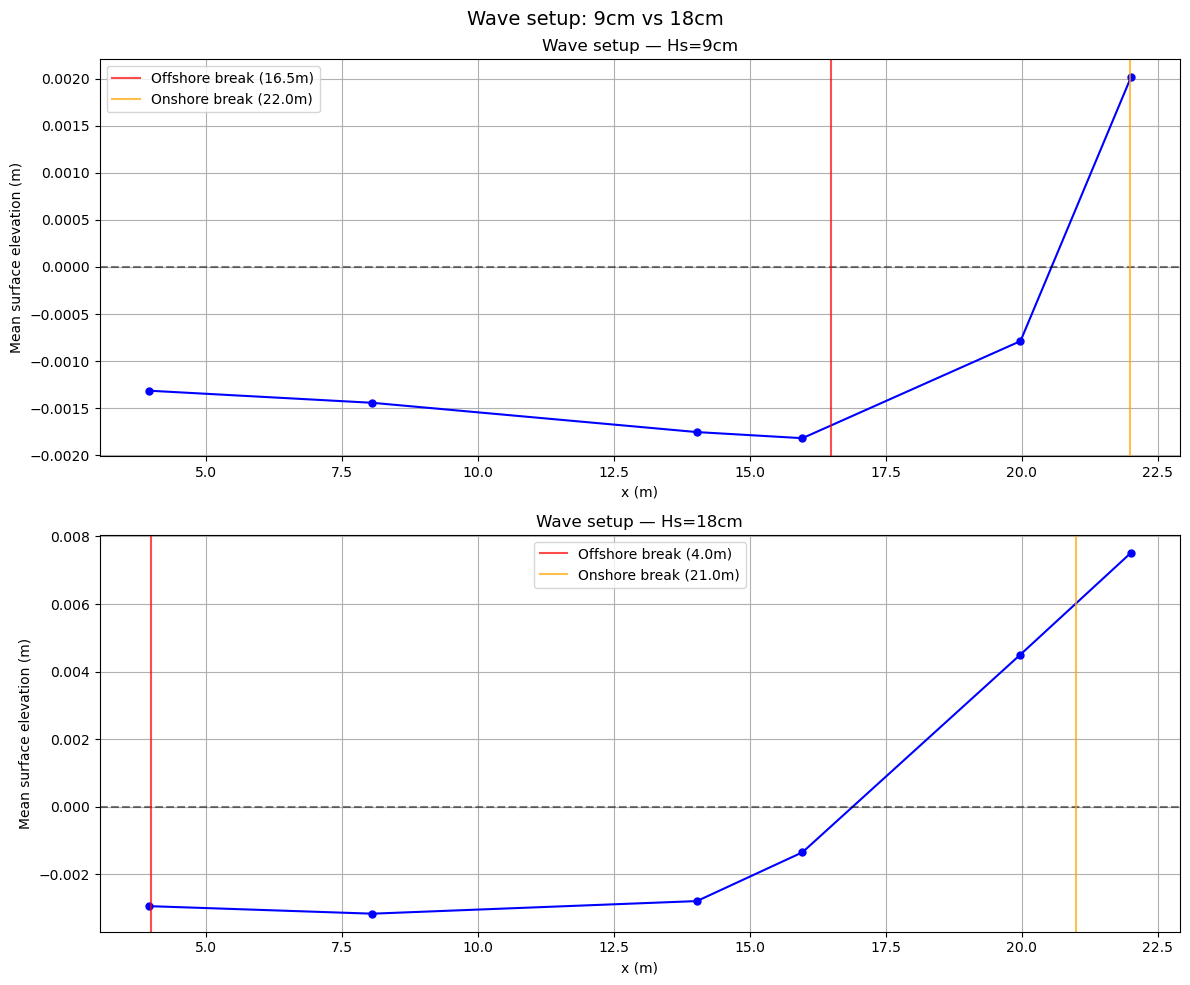

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

# ----------------------------------------------------------------
# Load data
# ----------------------------------------------------------------
def load_whm(filepath):
    raw  = np.genfromtxt(filepath, delimiter=";", skip_header=7)
    time = raw[:, 0]
    whms = [raw[:, i] for i in range(1, 7)]

    still = time < 60
    whms  = [w - np.mean(w[still]) for w in whms]

    mask  = (time >= 200) & (time <= time[-1] - 200)
    time  = time[mask]
    sens  = [0.0248, 0.0251, 0.0251, 0.0255, 0.0233, 0.0214]
    whms  = [w[mask] * s for w, s in zip(whms, sens)]
    return [time] + whms

cases     = [load_whm(f'Set{i}/WHM_test{i}.ASC') for i in range(1, 7)]
labels    = ['Hs=3cm', 'Hs=6cm', 'Hs=9cm', 'Hs=12cm', 'Hs=15cm', 'Hs=18cm']
positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]

# ----------------------------------------------------------------
# Core spectral function — returns f and E for one timeseries
# ----------------------------------------------------------------
def spectrum(data, Fs, nBlocks=12):
    nfft     = int(len(data) / nBlocks)
    nfft     = nfft - (nfft % 2)
    df       = Fs / nfft
    f        = np.arange(0, Fs/2 + df, df)
    blocks   = np.reshape(data[:nBlocks*nfft], (nBlocks, nfft))
    fft_data = 2 * fft(blocks, n=nfft, axis=1)[:, :len(f)] / nfft
    E        = np.mean(np.abs(fft_data)**2 / 2, axis=0) / df
    return f, E

def compute_stats(case, nBlocks=12):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    hm0, tp, tm01 = [], [], []
    for w in whms:
        f, E     = spectrum(w - np.mean(w), Fs, nBlocks)
        f1, E1   = f[1:], E[1:]
        m0       = np.trapz(E1, f1)
        m1       = np.trapz(E1 * f1, f1)
        hm0.append(4 * np.sqrt(m0))
        tp.append(1 / f1[np.argmax(E1)])
        tm01.append(m0 / m1)
    return hm0, tp, tm01

def plot_setup(time, WHM1, WHM2, WHM3, WHM4, WHM5, WHM6):
    whm_data      = [WHM1, WHM2, WHM3, WHM4, WHM5, WHM6]
    whm_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]
    setup = [np.mean(WHM) for WHM in whm_data]

    plt.figure(figsize=(8, 4))
    plt.plot(whm_positions, setup, color='blue', marker='o', markersize=6)
    plt.xlabel('x (m)', fontsize=12)
    plt.ylabel('Mean surface elevation (m)', fontsize=12)
    plt.title('Wave setup at WHM locations', fontsize=14)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.grid()
    plt.show()

# ----------------------------------------------------------------
# Plot 1: Hm0 cross-shore for all 6 cases
# ----------------------------------------------------------------
breakpoints = [(21.0,24.0),(18.2,23.0),(16.5,22.0),(13.0,22.0),(9.0,21.0),(4.0,21.0)]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for ax, case, label, (x_off, x_on) in zip(axes.flatten(), cases, labels, breakpoints):
    hm0, _, _ = compute_stats(case)
    ax.plot(positions, hm0, linestyle='--', marker='o', markersize=6, color='blue')
    ax.axvline(x=x_off, color='red',    alpha=0.7, label=f'Offshore break ({x_off}m)')
    ax.axvline(x=x_on,  color='orange', alpha=0.7, label=f'Onshore break ({x_on}m)')
    ax.set(xlabel='x (m)', ylabel='$H_{m0}$ (m)', title=f'$H_{{m0}}$ — {label}')
    ax.legend(fontsize=8); ax.grid()
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# Plot 2: Spectra for all 6 cases
# ----------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for ax, case, label in zip(axes.flatten(), cases, labels):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    for w, pos in zip(whms, positions):
        f, E = spectrum(w - np.mean(w), Fs)
        ax.plot(f, E, label=f'x={pos}m')
    ax.axvline(x=0.5,  linestyle='--', color='red',   alpha=0.5, label='Peak (2s)')
    ax.axvline(x=0.25, linestyle='--', color='green', alpha=0.5, label='IG cutoff')
    ax.set(xlim=(0,2), xlabel='Frequency (Hz)', ylabel='E (m²/Hz)', title=f'Spectra — {label}')
    ax.legend(fontsize=7); ax.grid()
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# Plot 3: Tp and Tm01 for all 6 cases
# ----------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
for ax, case, label in zip(axes.flatten(), cases, labels):
    _, tp, tm01 = compute_stats(case)
    ax.plot(positions, tp,   color='red',   marker='o', linestyle='--', markersize=4, label='Tp')
    ax.plot(positions, tm01, color='green', marker='o', linestyle='--', markersize=4, label='Tm01')
    ax.set(xlabel='x (m)', ylabel='Period (s)', title=label)
    ax.grid()
axes.flatten()[0].legend()
plt.suptitle('Cross-shore evolution of Tp and Tm01', fontsize=14)
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# Plot 4: Hm0, Tp/Tm01, Spectra for 3cm vs 18cm (1 col, 2 rows each)
# ----------------------------------------------------------------
case_3cm  = cases[0]
case_18cm = cases[5]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label, color, (x_off, x_on) in zip(axes, [case_3cm, case_18cm], ['Hs=3cm', 'Hs=18cm'], ['blue', 'red'], [breakpoints[0], breakpoints[5]]):
    hm0, _, _ = compute_stats(case)
    ax.plot(positions, hm0, color=color, marker='o', linestyle='--', markersize=5, label=label)
    ax.axvline(x=x_off, color='red',    alpha=0.7, label=f'Offshore break ({x_off}m)')
    ax.axvline(x=x_on,  color='orange', alpha=0.7, label=f'Onshore break ({x_on}m)')
    ax.set(xlabel='x (m)', ylabel='$H_{m0}$ (m)', title=f'$H_{{m0}}$ — {label}')
    ax.legend(); ax.grid()
plt.suptitle('Hm0 cross-shore: 3cm vs 18cm', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label in zip(axes, [case_3cm, case_18cm], ['Hs=3cm', 'Hs=18cm']):
    _, tp, tm01 = compute_stats(case)
    ax.plot(positions, tp,   color='red',   marker='o', linestyle='--', markersize=4, label='Tp')
    ax.plot(positions, tm01, color='green', marker='o', linestyle='--', markersize=4, label='Tm01')
    ax.set(xlabel='x (m)', ylabel='Period (s)', title=label)
    ax.legend(); ax.grid()
plt.suptitle('Tp and Tm01: 3cm vs 18cm', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label in zip(axes, [case_3cm, case_18cm], ['Hs=3cm', 'Hs=18cm']):
    time, *whms = case
    Fs = 1 / (time[1] - time[0])
    for w, pos in zip(whms, positions):
        f, E = spectrum(w - np.mean(w), Fs)
        ax.plot(f, E, label=f'x={pos}m')
    ax.axvline(x=0.5,  linestyle='--', color='red',   alpha=0.5, label='Peak (2s)')
    ax.axvline(x=0.25, linestyle='--', color='green', alpha=0.5, label='IG cutoff')
    ax.set(xlim=(0,2), xlabel='Frequency (Hz)', ylabel='E (m²/Hz)', title=f'Spectra — {label}')
    ax.legend(fontsize=7); ax.grid()
plt.suptitle('Spectra: 3cm vs 18cm', fontsize=14)
plt.tight_layout(); 
plt.show()

# --- All 6 subplots ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, case, label in zip(axes.flatten(), cases, labels):
    time, *whms = case
    ax.plot(positions, [np.mean(w) for w in whms], color='blue', marker='o', markersize=5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set(xlabel='x (m)', ylabel='Mean surface elevation (m)', title=f'Wave setup — {label}')
    ax.grid()
plt.suptitle('Wave setup', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, case, label, (x_off, x_on) in zip(axes, [cases[2], cases[5]], ['Hs=9cm', 'Hs=18cm'], [breakpoints[2], breakpoints[5]]):
    _, *whms = case
    ax.plot(positions, [np.mean(w) for w in whms], color='blue', marker='o', markersize=5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(x=x_off, color='red',    alpha=0.7, label=f'Offshore break ({x_off}m)')
    ax.axvline(x=x_on,  color='orange', alpha=0.7, label=f'Onshore break ({x_on}m)')
    ax.set(xlabel='x (m)', ylabel='Mean surface elevation (m)', title=f'Wave setup — {label}')
    ax.legend(); ax.grid()
plt.suptitle('Wave setup: 9cm vs 18cm', fontsize=14)
plt.tight_layout(); plt.show()